<a href="https://colab.research.google.com/github/kanishka-14/Banking_Securities_Fraud_And_AnomalyDetection/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Assigning column names (from dataset structure)
columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

train_df = pd.read_csv('/content/twitter_training.csv', header=None, names=columns)
val_df = pd.read_csv('/content/twitter_validation.csv', header=None, names=columns)

# Combine them
df = pd.concat([train_df, val_df], ignore_index=True)


In [5]:
import re

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # remove URLs
    text = re.sub(r'\@\w+|\#','', text)  # remove mentions & hashtags
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    return text

df['Clean_Tweet'] = df['Tweet'].apply(clean_tweet)


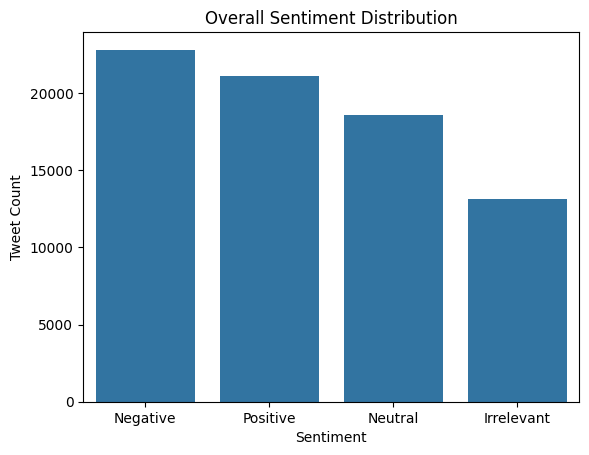

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Sentiment', order=df['Sentiment'].value_counts().index)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()


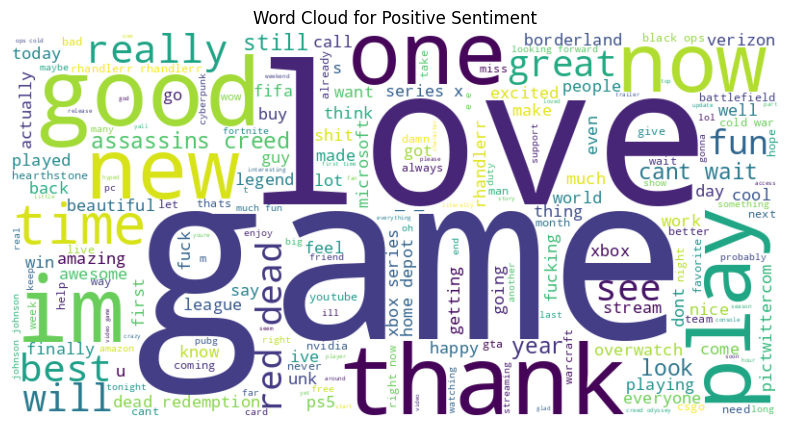

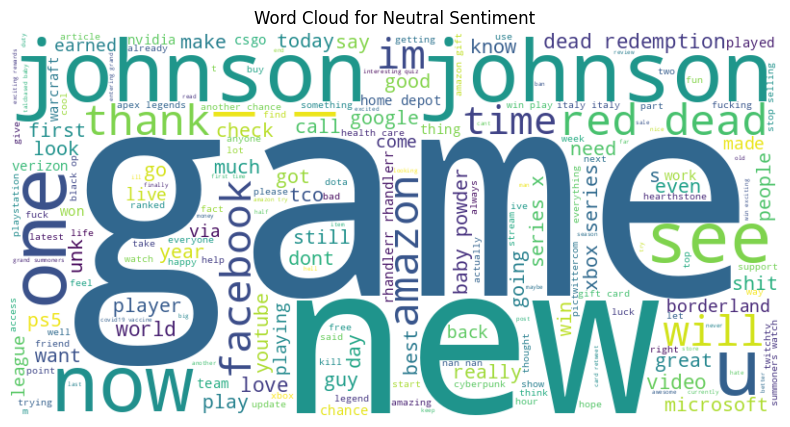

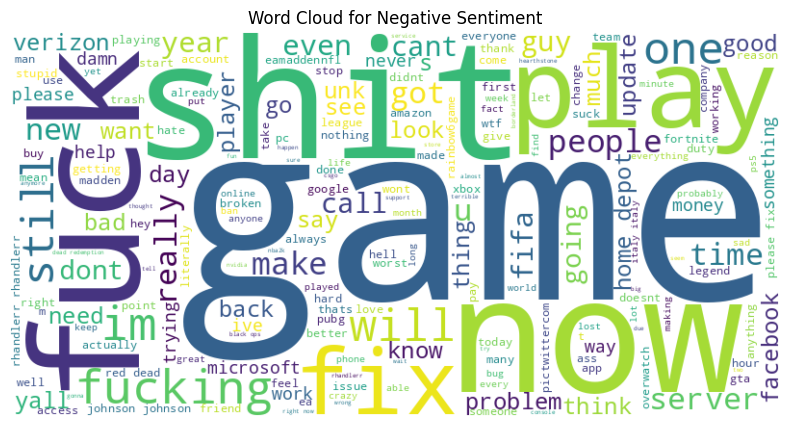

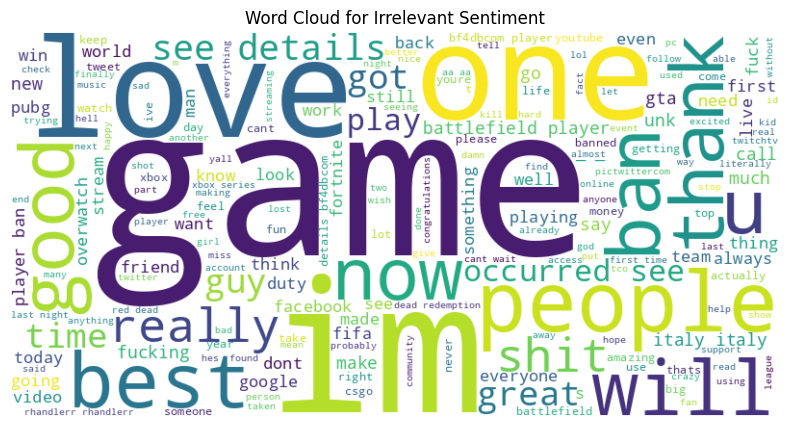

In [7]:
from wordcloud import WordCloud

for sentiment in df['Sentiment'].unique():
    text = ' '.join(df[df['Sentiment'] == sentiment]['Clean_Tweet'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {sentiment} Sentiment")
    plt.axis('off')
    plt.show()


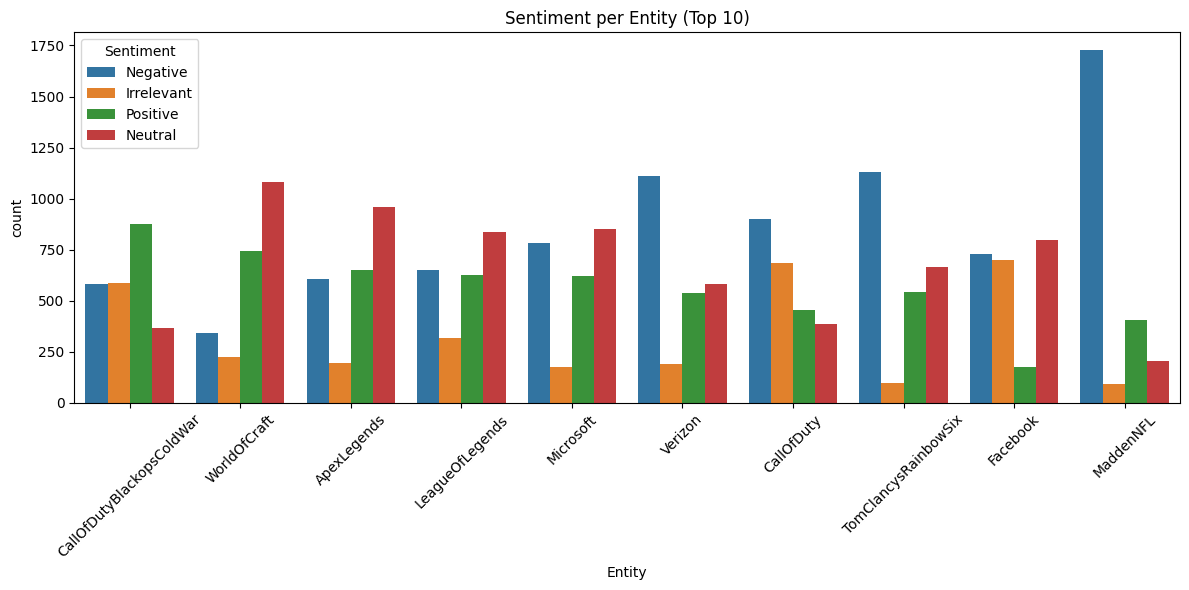

In [8]:
top_entities = df['Entity'].value_counts().head(10).index
subset = df[df['Entity'].isin(top_entities)]

plt.figure(figsize=(12,6))
sns.countplot(data=subset, x='Entity', hue='Sentiment')
plt.title("Sentiment per Entity (Top 10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()
df['VADER_Compound'] = df['Clean_Tweet'].apply(lambda x: sid.polarity_scores(x)['compound'])


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


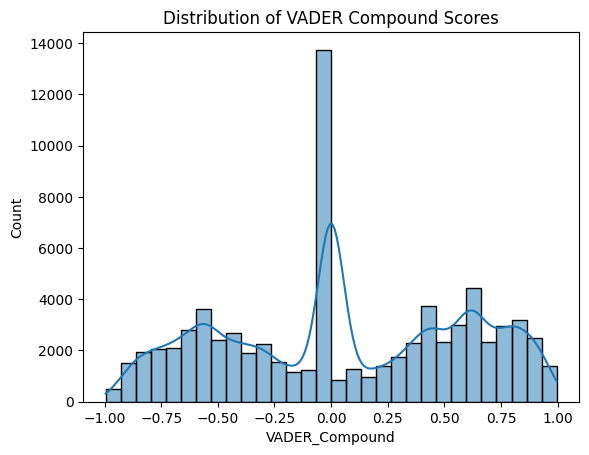

In [10]:
sns.histplot(data=df, x='VADER_Compound', kde=True, bins=30)
plt.title("Distribution of VADER Compound Scores")
plt.show()
